In [8]:
import zipfile
import os
import pandas as pd
import numpy as np
import json
import ast

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# 1. Unzip archive.zip if CSVs are not extracted yet
if not os.path.exists("tmdb_5000_movies.csv"):
    with zipfile.ZipFile("archive.zip", "r") as zip_ref:
        zip_ref.extractall(".")

# 2. Load CSV files
movies_df = pd.read_csv("tmdb_5000_movies.csv")
credits_df = pd.read_csv("tmdb_5000_credits.csv")

# 3. Merge on 'title' to define 'movies'
movies = movies_df.merge(credits_df, on='title')

# 4. Helper functions to parse stringified JSON columns
def get_list(obj):
    if isinstance(obj, str):
        try:
            return [i['name'] for i in ast.literal_eval(obj)]
        except:
            return []
    return []

def get_cast(obj):
    if isinstance(obj, str):
        try:
            return [i['name'] for i in ast.literal_eval(obj)[:3]] # Top 3 actors
        except:
            return []
    return []

def get_director(obj):
    if isinstance(obj, str):
        try:
            for i in ast.literal_eval(obj):
                if i['job'] == 'Director':
                    return [i['name']]
            return []
        except:
            return []
    return []

# 5. Sanitize & transform JSON fields
movies['genres'] = movies['genres'].apply(get_list)
movies['keywords'] = movies['keywords'].apply(get_list)
movies['cast'] = movies['cast'].apply(get_cast)
movies['crew'] = movies['crew'].apply(get_director)

# 6. Process text overview and build combined 'tags_string'
movies['overview'] = movies['overview'].fillna('')
movies['overview_list'] = movies['overview'].apply(lambda x: x.split())

# Remove spaces inside multi-word names/genres (e.g., 'Johnny Depp' -> 'JohnnyDepp')
for col in ['genres', 'keywords', 'cast', 'crew']:
    movies[col] = movies[col].apply(lambda x: [i.replace(" ", "") for i in x])

# Combine into single metadata string per movie
movies['tags'] = movies['overview_list'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']
movies['tags_string'] = movies['tags'].apply(lambda x: " ".join(x).lower())

print("✅ Data successfully loaded, merged, and transformed!")
print(f"Shape: {movies.shape}")
movies[['title', 'tags_string']].head(3)

✅ Data successfully loaded, merged, and transformed!
Shape: (4809, 26)


,title,tags_string
0,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,Spectre,a cryptic message from bond’s past sends him o...


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# Initialize TF-IDF Vectorizer (removing common English stop words)
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

# Construct the TF-IDF feature matrix
tfidf_matrix = tfidf.fit_transform(movies['tags_string'])

# Compute Cosine Similarity matrix
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

# Create a mapping of movie titles to dataset indices
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

# Recommender Function
def recommend_movie(title, top_n=5):
    # Retrieve movie index
    if title not in indices:
        return f"Movie '{title}' not found in dataset. Please try another title."

    idx = indices[title]

    # Get pairwise similarity scores for all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort movies based on similarity scores in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top_n most similar movies (excluding the searched movie itself at index 0)
    sim_scores = sim_scores[1:top_n+1]

    # Fetch movie indices and titles
    movie_indices = [i[0] for i in sim_scores]

    recommendations = pd.DataFrame({
        'Recommended Movie': movies['title'].iloc[movie_indices].values,
        'Similarity Score': [round(i[1], 4) for i in sim_scores]
    })

    return recommendations

# Test recommendation engine
print("Recommender system built successfully!\n")
print("--- Recommendations for 'The Dark Knight' ---")
display(recommend_movie('The Dark Knight'))

print("\n" + "="*45 + "\n")

print("--- Recommendations for 'Avatar' ---")
display(recommend_movie('Avatar'))

Recommender system built successfully!

--- Recommendations for 'The Dark Knight' ---


,Recommended Movie,Similarity Score
0,The Dark Knight Rises,0.4560
1,Batman Returns,0.3830
2,Batman Begins,0.3664
3,Batman Forever,0.3032
4,"Batman: The Dark Knight Returns, Part 2",0.2917




--- Recommendations for 'Avatar' ---


,Recommended Movie,Similarity Score
0,Falcon Rising,0.2088
1,Battle: Los Angeles,0.1989
2,Apollo 18,0.1884
3,Star Trek Into Darkness,0.1754
4,Titan A.E.,0.1693


/tmp/ipykernel_717/1051339917.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


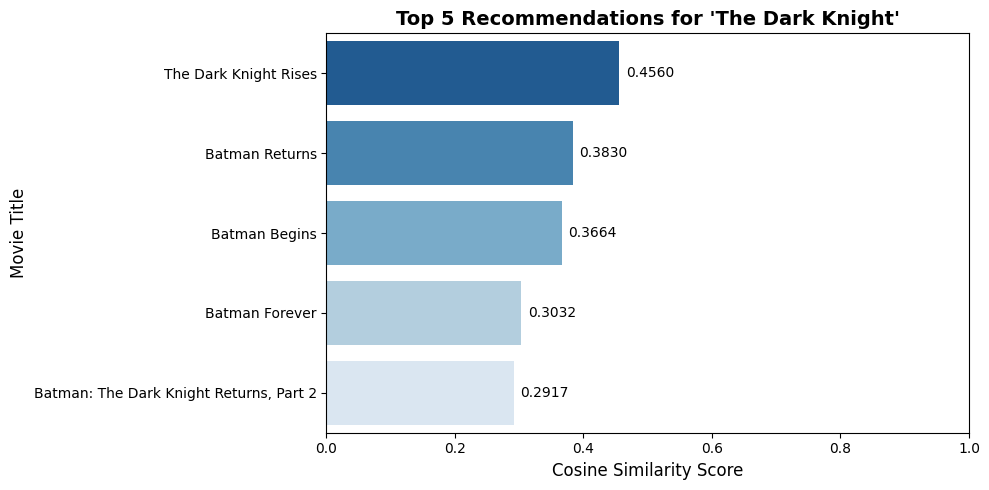

/tmp/ipykernel_717/1051339917.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


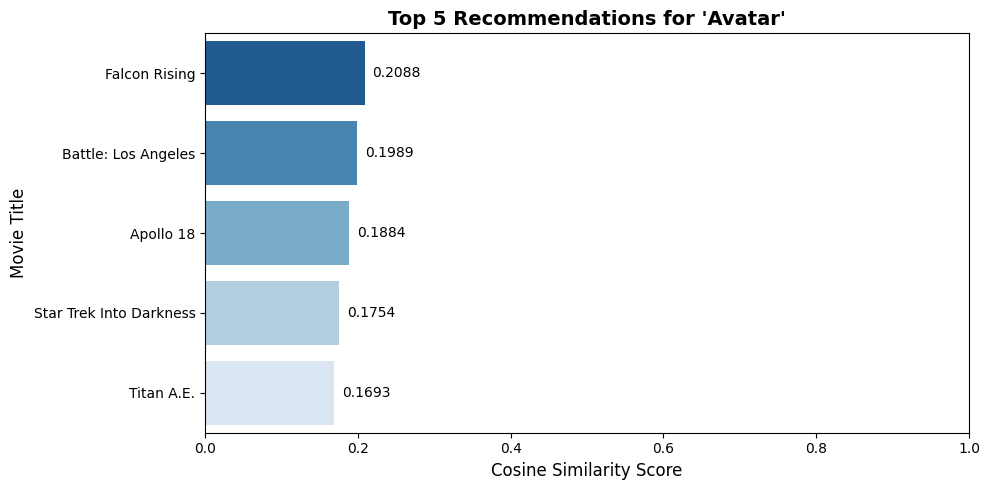

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_recommendations(movie_title, top_n=5):
    rec_df = recommend_movie(movie_title, top_n=top_n)

    if isinstance(rec_df, str):
        print(rec_df)
        return

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=rec_df,
        x='Similarity Score',
        y='Recommended Movie',
        palette='Blues_r'
    )
    plt.title(f"Top {top_n} Recommendations for '{movie_title}'", fontsize=14, fontweight='bold')
    plt.xlabel("Cosine Similarity Score", fontsize=12)
    plt.ylabel("Movie Title", fontsize=12)
    plt.xlim(0, 1)

    # Annotate score values on the bars
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f"{width:.4f}",
                    (width + 0.01, p.get_y() + p.get_height() / 2.),
                    va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

# Run visual plot for two test cases
plot_recommendations('The Dark Knight')
plot_recommendations('Avatar')